# MedQA Logic Divergence Case Study Analysis
This notebook performs a case study on the `medqa_logic_divergence_full_v2_filtered.json` dataset.
It includes data cleaning, text mining of error patterns, statistical analysis of model continuation performance, and visual tools for manual review of specific medical QA logic breaks.

In [ ]:
# 基础依赖导入：数据处理、绘图、词云等
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 设定绘图风格与默认尺寸，便于统一输出
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [ ]:
# 加载数据集并展开嵌套字段
file_path = 'logs/medqa_logic_divergence_full_v2_filtered.json'

# 读取原始 JSON
with open(file_path, 'r') as f:
    data = json.load(f)

# 转为 DataFrame 便于后续处理
df = pd.DataFrame(data)

# 展开 review_details 字段，前缀标记为 review_
review_df = df['review_details'].apply(pd.Series)
df = pd.concat([df.drop(['review_details'], axis=1), review_df.add_prefix('review_')], axis=1)

# 展开 small_model 字段，前缀标记为 small_model_
small_model_df = df['small_model'].apply(pd.Series)
df = pd.concat([df.drop(['small_model'], axis=1), small_model_df.add_prefix('small_model_')], axis=1)

# 如需分析大模型，可解注释下方代码展开 big_model
# big_model_df = df['big_model'].apply(pd.Series)
# df = pd.concat([df.drop(['big_model'], axis=1), big_model_df.add_prefix('big_model_')], axis=1)

print(f"Successfully loaded {len(df)} cases.")
df.head(2)

Successfully loaded 42 cases.


,id,ground_truth,error_phrase_identified,prefix_context,big_model,review_thought,review_phrase,review_explanation,review_raw_gen,small_model_next_token_top5,small_model_continuation,small_model_extracted_answer,small_model_is_correct_continuation
0,366,A,The best match among the options is B. Myocard...,1. **Analyze the question and understand what ...,"{'next_token_top5': [{'token': 'B', 'prob': 1....",analysis,The best match among the options is B. Myocard...,The student incorrectly chose myocardial infar...,"{""thought"": ""analysis"", ""first_wrong_phrase"": ...","[{'token': 'B', 'prob': 1.0, 'token_id': 33}, ...",B. Myocardial infarction** \nMyocardial infar...,A,True
1,1159,A,The anaerobic culture of peritoneal fluid show...,1. **Analyze the question and understand what ...,"{'next_token_top5': [{'token': 'C', 'prob': 1....",analysis,The anaerobic culture of peritoneal fluid show...,The student correctly identifies Bacteroides f...,"{""thought"": ""analysis"", ""first_wrong_phrase"": ...","[{'token': 'C', 'prob': 1.0, 'token_id': 34}, ...",C. Clostridium perfringens** \n - *Clostridi...,A,True


In [ ]:
# Section 3: 数据总览与基础统计
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# 计算解释与错误短语的文本长度，便于观察描述丰富度
df['explanation_len'] = df['review_explanation'].dropna().apply(len)
df['error_phrase_len'] = df['error_phrase_identified'].dropna().apply(len)

print("\n--- 文本长度统计 ---")
print(df[['explanation_len', 'error_phrase_len']].describe())

# 检查各列数据类型
dprint = df.dtypes
print("\nData Types:\n", dprint)

Dataset Shape: (42, 13)

Missing Values:
 id                                     0
ground_truth                           0
error_phrase_identified                0
prefix_context                         0
big_model                              0
review_thought                         0
review_phrase                          0
review_explanation                     0
review_raw_gen                         0
small_model_next_token_top5            0
small_model_continuation               0
small_model_extracted_answer           0
small_model_is_correct_continuation    0
dtype: int64

--- Text Length Statistics ---
       explanation_len  error_phrase_len
count        42.000000         42.000000
mean        476.595238        149.666667
std         135.416442         75.448469
min         246.000000         43.000000
25%         388.750000        101.750000
50%         443.000000        133.000000
75%         533.750000        181.750000
max         861.000000        368.000000

Data Types

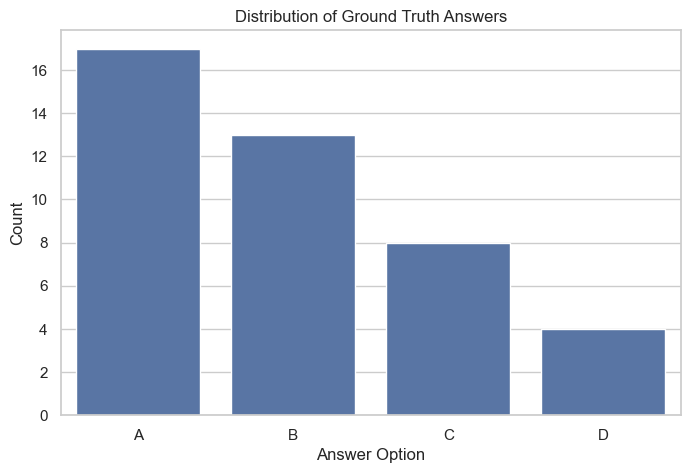

In [ ]:
# Section 4: Ground Truth 选项分布
plt.figure(figsize=(8, 5))
sns.countplot(x='ground_truth', data=df, order=sorted(df['ground_truth'].unique()))
plt.title('Distribution of Ground Truth Answers')
plt.xlabel('Answer Option')
plt.ylabel('Count')
plt.show()

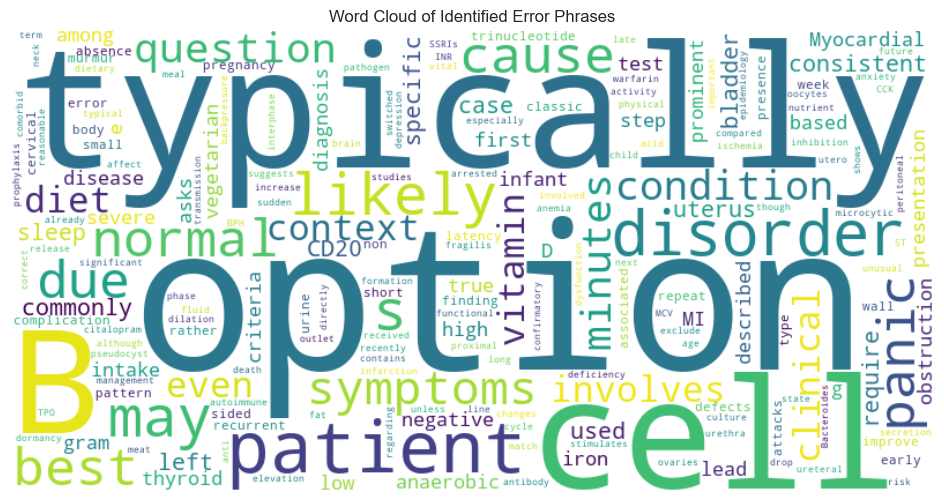

In [ ]:
# Section 5: 错误短语文本分析（词云）
# 汇总错误短语，生成词云以直观看常见错误模式
text_combined = " ".join(df['error_phrase_identified'].dropna().astype(str).tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Identified Error Phrases')
plt.show()

Small Model Continuation Accuracy: 100.00%


ValueError: zip() argument 2 is shorter than argument 1

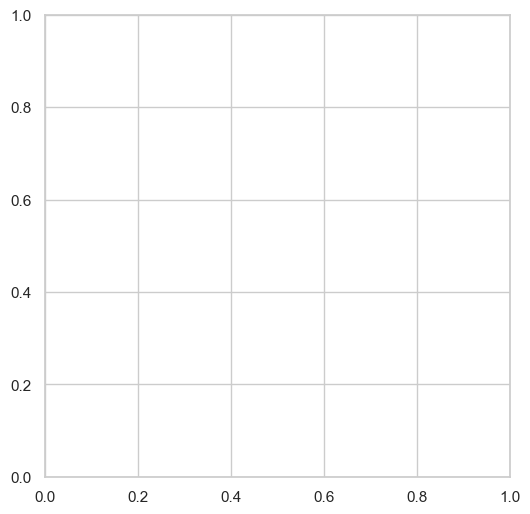

In [ ]:
# Section 6: 小模型续写准确率
# 计算小模型在截断续写上的准确率
accuracy = df['small_model_is_correct_continuation'].mean()
print(f"Small Model Continuation Accuracy: {accuracy:.2%}")

# 饼图展示正确/错误比例
plt.figure(figsize=(6, 6))
df['small_model_is_correct_continuation'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, labels=['Correct', 'Incorrect']
)
plt.title('Small Model Continuation Accuracy')
plt.ylabel('')
plt.show()

In [ ]:
# Section 7: 案例深潜函数
from IPython.display import display, Markdown

# 按案例 ID 展示完整信息，便于定性分析
def display_case_study(case_id):
    # 过滤指定案例并取第一行
    case = df[df['id'] == str(case_id)].iloc[0]
    
    display(Markdown(f"### Case ID: {case['id']}"))
    display(Markdown(f"**Ground Truth:** {case['ground_truth']}"))
    
    display(Markdown("#### Prefix Context"))
    display(Markdown(f"{case['prefix_context']}..."))
    
    display(Markdown("#### Error Phrase Identified"))
    display(Markdown(f"> {case['error_phrase_identified']}"))
    
    display(Markdown("#### Human Review Explanation"))
    display(Markdown(f"{case['review_explanation']}"))

    display(Markdown("#### Small Model Continuation"))
    is_correct = case['small_model_is_correct_continuation']
    status = "✅ Correct" if is_correct else "❌ Incorrect"
    display(Markdown(f"**Status:** {status}"))
    display(Markdown(f"**Continuation:** {case['small_model_continuation']}"))
    
    # 如果有 top-5 logits/probabilities，则打印以便进一步诊断
    if 'small_model_next_token_top5' in case and isinstance(case['small_model_next_token_top5'], list) and len(case['small_model_next_token_top5']) > 0:
         display(Markdown("#### Top 5 Logits/Probs"))
         print(case['small_model_next_token_top5'])

# 示例：展示 366 案例（如不存在则提示）
try:
    display_case_study(366)
except IndexError:
    print("Case ID 366 not found in the filtered dataset.")

In [ ]:
# Section 8: 关键词筛选案例
keywords = ['diabetes', 'cardiac', 'neurology', 'heart', 'brain']

# 在 prefix_context 中按关键词过滤
mask = df['prefix_context'].str.contains('|'.join(keywords), case=False, na=False)
filtered_df = df[mask]

print(f"Found {len(filtered_df)} cases matching keywords: {keywords}")

if len(filtered_df) > 0:
    # 随机抽取一个案例并展示细节
    sample_id = filtered_df.sample(1)['id'].values[0]
    print(f"\nRandomly selected case ID: {sample_id}")
    display_case_study(sample_id)
else:
    print("No cases found with the specified keywords.")